In [ ]:
# Install required libraries (ensure you are using a GPU runtime for training!)
!pip install roboflow ultralytics pandas matplotlib opencv-python-headless seaborn
!pip install protobuf==3.20.3 # Fixes potential Protobuf version conflicts

import os
import cv2
import glob
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from roboflow import Roboflow
from datetime import datetime # Needed for historical logging

# --- 🎯 CRITICAL USER CONFIGURATION ---
# 1. Image Scaling Reference
KNOWN_REFERENCE_WIDTH_INCHES = 18.0

# 2. Model Classes
CORRECT_CLASS = "qblock"
INCORRECT_CLASS = "incorrect qblock"
CONFIDENCE_THRESHOLD = 0.5
IGNORED_CLASSES = {
    "backgroundclutter", "smallqblock", "faded-qblock", "faded-smallqblock"
}
EXPECTED_QBLOCK_COUNT = 14

# 3. PdM & QC THRESHOLDS (MUST be tuned based on your baseline data)
# QC_FAILURE_LIMITS: Triggers a FAIL_COLOR/FAIL_DIMENSION result (3-Sigma Control Limit)
QC_MAX_BRIGHTNESS = 150       # Max brightness allowed before failure (higher = more faded)
QC_MIN_WIDTH_IN = 0.30        # Min average width allowed before failure (smaller = shrunken)

# PdM_WARNING_LIMITS: Triggers a maintenance WARNING (2-Sigma Control Limit)
# Set warning limits slightly inside the failure limits to predict the issue.
PDM_WARNING_BRIGHTNESS = 140  # Maintenance alert if brightness exceeds this
PDM_WARNING_MIN_WIDTH_IN = 0.32 # Maintenance alert if avg width drops below this
HISTORY_FILE_PATH = 'qc_trend_history.csv' # File to log historical metrics

# ------------------------------------------

# --- Roboflow Download and Path Setup ---
print("--- 🛠️ Phase 1: Setup and Data Download ---")

# Execute your Roboflow download
rf = Roboflow(api_key="34aeVIOAX5XcJCubVAHR")
project = rf.workspace("nissha-medical").project("eagle-eyes-tbhgj")
version = project.version(23)
dataset = version.download("yolov8")

dataset_root_path = dataset.location
config_path = os.path.join(dataset_root_path, 'data.yaml')

# --- Load YAML to get Class IDs ---
def load_class_map(config_path):
    with open(config_path, "r") as f:
        data = yaml.safe_load(f)
    names = data["names"]
    if isinstance(names, list):
        return {name: idx for idx, name in enumerate(names)}
    elif isinstance(names, dict):
        return {v: k for k, v in names.items()}
    raise ValueError("Invalid 'names:' format in YAML.")

class_map = load_class_map(config_path)
correct_id = class_map[CORRECT_CLASS]
incorrect_id = class_map[INCORRECT_CLASS]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 40.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
   

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- 🛠️ Phase 1: Setup and Data Download ---
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to eagle-eyes-23 in yolov8:: 100%|██████████| 6396/6396 [00:01<00:00, 5867.02it/s]


## Utility functions


In [ ]:
# --- UTILITY FUNCTIONS ---

# 1. Color Extraction
def get_avg_color_and_hex(img_array, xmin, ymin, xmax, ymax):
    """Calculates the average color (RGB), Hex code, and Brightness for a detected bounding box."""
    h, w = img_array.shape[:2]
    xmin, ymin = max(0, xmin), max(0, ymin)
    xmax, ymax = min(w, xmax), min(h, ymax)

    cropped_img = img_array[ymin:ymax, xmin:xmax]

    if cropped_img.size == 0:
        return 0, 0, 0, '#000000', 0

    avg_color = cv2.mean(cropped_img)[:3]
    b, g, r = avg_color

    hex_color = '#%02x%02x%02x' % (int(r), int(g), int(b))
    avg_brightness = (int(r) + int(g) + int(b)) / 3 # Simple fading metric

    return int(r), int(g), int(b), hex_color, avg_brightness

# 2. Dimension Extraction
def get_dimensions_in_inches(img_width, xmin, xmax, ymin, ymax, ref_width_in):
    """Calculates QBlock dimensions in inches using the PPM scaling factor."""
    if img_width == 0:
        return 0.0, 0.0

    PPM = img_width / ref_width_in

    width_pixels = xmax - xmin
    height_pixels = ymax - ymin

    width_inches = width_pixels / PPM
    height_inches = height_pixels / PPM

    return round(width_inches, 4), round(height_inches, 4)

# 3. PdM Trend Logging (NEW)
def log_qc_summary_for_trending(qc_summary_df, history_file_path):
    """
    Appends the aggregated QC metrics from the current run to a persistent CSV file
    for long-term predictive trending.
    """
    # Create the timestamp for the current run
    current_time = datetime.now()

    # Calculate the AVERAGE of the key trending metrics across the entire run
    # This represents the overall machine state for this batch/time period
    avg_metrics = qc_summary_df.agg({
        'Avg_Width': 'mean',
        'Max_Brightness': 'mean',
        'Max_Delta_E': 'mean'
    }).to_dict()

    new_log = {
        'Timestamp': [current_time],
        'Batch_ID': [current_time.strftime("%Y%m%d%H%M")], # Use timestamp as a unique batch ID
        'Avg_Width_Trend': [avg_metrics['Avg_Width']],
        'Max_Brightness_Trend': [avg_metrics['Max_Brightness']],
        'Max_Delta_E_Trend': [avg_metrics['Max_Delta_E']]
    }
    df_new_row = pd.DataFrame(new_log)

    # Append to the historical file
    if os.path.exists(history_file_path):
        # Append without header
        df_new_row.to_csv(history_file_path, mode='a', header=False, index=False)
    else:
        # Create new file with header
        df_new_row.to_csv(history_file_path, index=False)

    print(f"\nSuccessfully logged current metrics for PdM trending to: {history_file_path}")

## Model training

In [ ]:
# --- 🧠 Phase 2: Training YOLOv8 Model ---
print("\n--- 🧠 Phase 2: Training YOLOv8 Model ---")
print("Loading pre-trained YOLOv8n model...")

try:
    model = YOLO('yolov8n.pt')

    # Train the Model
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10, # Use 50+ for production accuracy
        imgsz=640,
        batch=-1,
        name='yolov8n_qc_detector'
    )

    print("\n--- Training complete! ---")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')

except Exception as e:
    print(f"FATAL ERROR during training. Error: {e}")
    best_model_path = None


--- 🧠 Phase 2: Training YOLOv8 Model ---
Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-23/data.yaml
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-23/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_

## Inference and Integrated Data Collection

In [ ]:
# --- 📏 Phase 3: Inference and Integrated Data Collection ---

if not os.path.exists(best_model_path):
    print(f"FATAL ERROR: Trained weights not found at {best_model_path}. Please re-run Cell 3.")
else:
    print("\n=== Loading best model for inference ===")
    model = YOLO(best_model_path)

    # Load test images
    test_dir = os.path.join(dataset_root_path, "test", "images")
    test_images = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
        test_images.extend(glob.glob(os.path.join(test_dir, ext)))
    print(f"Found {len(test_images)} test images for inference.")

    # Storage for all block data
    all_blocks = []
    all_image_results = []

    print("\n=== Running inference and extracting features ===")

    # Run batch prediction for speed
    results = model.predict(
        source=test_images,
        conf=CONFIDENCE_THRESHOLD,
        save=False,
        verbose=False,
        classes=[correct_id, incorrect_id]
    )

    for img_path, result in zip(test_images, results):
        img_name = os.path.basename(img_path)
        img = cv2.imread(img_path)

        if img is None: continue
        (img_height, img_width) = img.shape[:2]

        # Ground truth from filename
        ground_truth = "GOOD" if "_OK" in img_name.upper() else "NOT_GOOD" if "_NG" in img_name.upper() else "UNKNOWN"

        correct_count = 0
        incorrect_count = 0

        for i, box in enumerate(result.boxes):
            class_id = int(box.cls.cpu().item())

            if class_id == correct_id:
                correct_count += 1
            elif class_id == incorrect_id:
                incorrect_count += 1

            xmin, ymin, xmax, ymax = box.xyxy[0].cpu().numpy().astype(int)

            # Extract Features
            r, g, b, hex_color, brightness = get_avg_color_and_hex(img, xmin, ymin, xmax, ymax)
            width_in, height_in = get_dimensions_in_inches(img_width, xmin, xmax, ymin, ymax, KNOWN_REFERENCE_WIDTH_INCHES)

            # Store Block-level data
            all_blocks.append({
                "image_name": img_name, # Correct column name
                "class_name": result.names[class_id],
                "r": r, "g": g, "b": b,
                "Brightness": brightness,
                "Width_in": width_in,
                "Height_in": height_in,
                "Confidence": round(float(box.conf.cpu().item()), 4)
            })

        # Store Image-level summary
        all_image_results.append({
            "image_name": img_name,
            "ground_truth": ground_truth,
            "correct_count": correct_count,
            "incorrect_count": incorrect_count
        })

    # Create final DataFrames
    df_blocks = pd.DataFrame(all_blocks)
    df_images = pd.DataFrame(all_image_results)

    # Save CSV of all block-level data
    results_dir = "results_qc_pipeline"
    os.makedirs(results_dir, exist_ok=True)
    block_output_path = os.path.join(results_dir, "master_block_data_qc.csv")
    df_blocks.to_csv(block_output_path, index=False)
    print(f"\nSaved master block-level data: {block_output_path}")


=== Loading best model for inference ===
Found 138 test images for inference.

=== Running inference and extracting features ===

Saved master block-level data: results_qc_pipeline/master_block_data_qc.csv


## Real-Time QC and Historical Logging

In [ ]:
# --- 📊 Phase 4: Real-Time QC and Historical Logging ---
if df_blocks.empty:
    print("\nFATAL ERROR: No block data collected. Cannot run analysis.")
else:
    # 1. --- Compute Color Delta E Baseline (Fading Metric) ---
    correct_df = df_blocks[df_blocks["class_name"] == CORRECT_CLASS]
    ref_r, ref_g, ref_b = correct_df[['r', 'g', 'b']].median() if not correct_df.empty else (255, 255, 255)

    df_blocks['Delta_E'] = np.sqrt(
        (df_blocks['r'] - ref_r)**2 + (df_blocks['g'] - ref_g)**2 + (df_blocks['b'] - ref_b)**2
    )

    # 2. --- Aggregate Block Data to Image Level ---
    qc_summary_df = df_blocks.groupby('image_name').agg(
        Block_Count=('image_name', 'size'),
        Correct_Count=('class_name', lambda x: (x == CORRECT_CLASS).sum()),
        Incorrect_Count=('class_name', lambda x: (x == INCORRECT_CLASS).sum()),
        Avg_Width=('Width_in', 'mean'),
        Std_Width=('Width_in', 'std'),
        Max_Brightness=('Brightness', 'max'),
        Max_Delta_E=('Delta_E', 'max')
    ).reset_index()

    qc_summary_df = pd.merge(qc_summary_df, df_images[['image_name', 'ground_truth']],
                             on='image_name', how='left')


    # 3. --- Combined Real-Time QC Decision ---
    def check_qc_criteria(row):
        """Applies combined dimension, color, and count FAILURE criteria (3-Sigma)."""

        # Check 1: Block Count / Quality Failure
        if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT and row['Incorrect_Count'] > 0:
            return 'FAIL_QUALITY'
        if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT:
            return 'FAIL_COUNT'

        # Check 2: Dimensional Failure (QC_MIN_WIDTH_IN is the lower control limit)
        if row['Avg_Width'] < QC_MIN_WIDTH_IN:
            return 'FAIL_DIMENSION'

        # Check 3: Fading Failure (QC_MAX_BRIGHTNESS is the upper control limit)
        if row['Max_Brightness'] > QC_MAX_BRIGHTNESS:
            return 'FAIL_COLOR'

        return 'PASS'

    qc_summary_df['QC_PREDICTION'] = qc_summary_df.apply(check_qc_criteria, axis=1)

    # 4. --- Log Metrics for PdM Trending ---
    log_qc_summary_for_trending(qc_summary_df, HISTORY_FILE_PATH)

    # 5. --- Summarize Real-Time Accuracy ---
    total_scorable = len(qc_summary_df[qc_summary_df['ground_truth'] != 'UNKNOWN'])

    print("\n=== Real-Time QC Accuracy ===")
    print(f"Total Test Images Scored: {total_scorable}")

    summary_output_path = os.path.join(results_dir, "final_qc_summary.csv")
    qc_summary_df.to_csv(summary_output_path, index=False)
    print(f"Saved real-time QC summary to: {summary_output_path}")


Successfully logged current metrics for PdM trending to: qc_trend_history.csv

=== Real-Time QC Accuracy ===
Total Test Images Scored: 132
Saved real-time QC summary to: results_qc_pipeline/final_qc_summary.csv


## Predictive Maintenance (PdM) Analysis and Control Charts


=== Predictive Maintenance Analysis ===
Found 1 historical data points.

--- Current Machine Health (Latest Batch) ---
🚨 PDM WARNING (Fading): Brightness (142.91) exceeds Warning Limit (140). Maintenance Alert!
✅ Dimension: Within Warning Limits.


invalid escape sequence '\D'
invalid escape sequence '\D'
invalid escape sequence '\D'


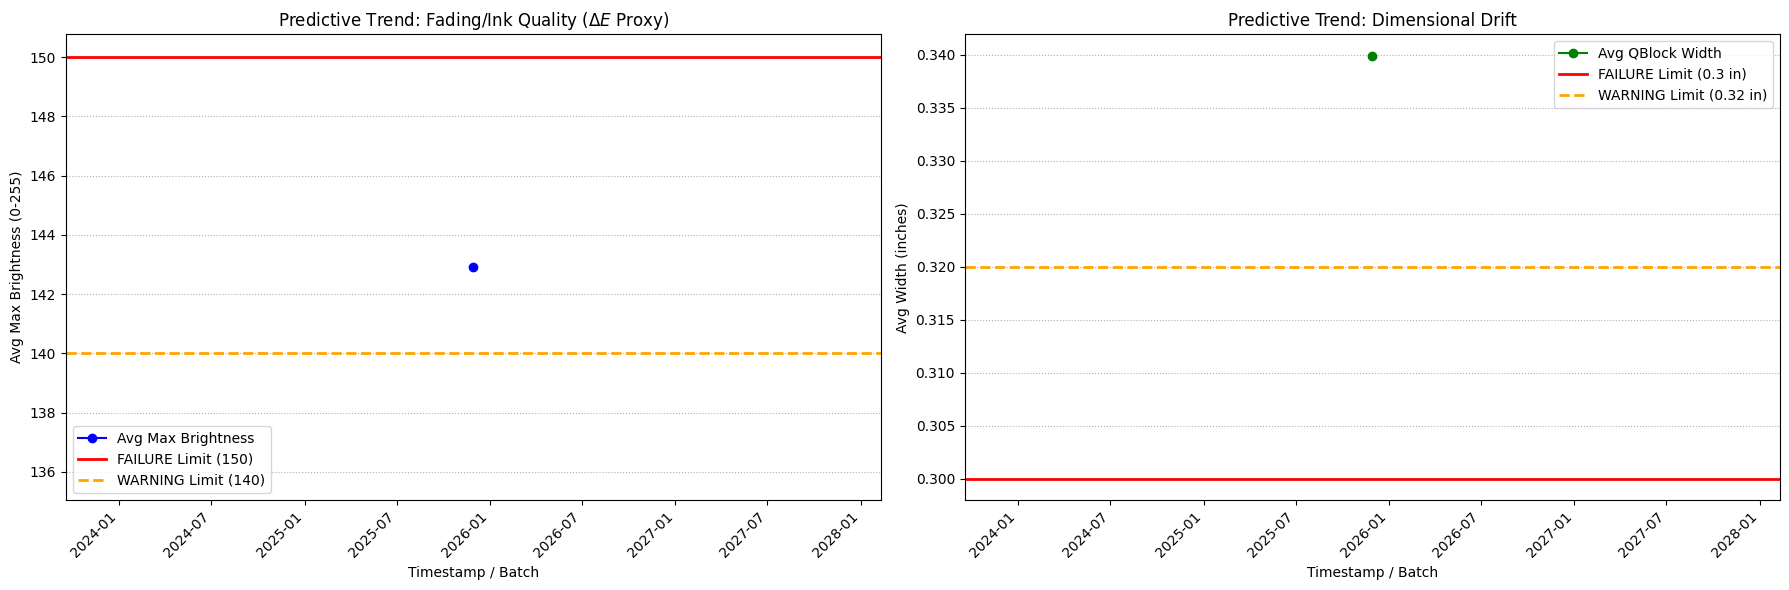


--- Predictive System Ready ---
Monitor the charts for gradual drift toward the orange/red lines to trigger maintenance.


In [ ]:
# --- 🚀 Phase 5: Predictive Maintenance (PdM) Trending ---

if not os.path.exists(HISTORY_FILE_PATH):
    print(f"\nFATAL ERROR: History file not found at {HISTORY_FILE_PATH}. Run Cell 5 multiple times to generate history.")
else:
    df_history = pd.read_csv(HISTORY_FILE_PATH)
    # Ensure Timestamp is a datetime object for plotting
    df_history['Timestamp'] = pd.to_datetime(df_history['Timestamp'])

    print("\n=== Predictive Maintenance Analysis ===")
    print(f"Found {len(df_history)} historical data points.")

    # --- PdM Warning Check (Predictive Alarm) ---
    last_row = df_history.iloc[-1]

    print("\n--- Current Machine Health (Latest Batch) ---")

    # 1. Fading Check
    if last_row['Max_Brightness_Trend'] > PDM_WARNING_BRIGHTNESS:
        print(f"🚨 PDM WARNING (Fading): Brightness ({last_row['Max_Brightness_Trend']:.2f}) exceeds Warning Limit ({PDM_WARNING_BRIGHTNESS}). Maintenance Alert!")
    else:
        print("✅ Fading: Within Warning Limits.")

    # 2. Dimension Check
    if last_row['Avg_Width_Trend'] < PDM_WARNING_MIN_WIDTH_IN:
        print(f"🚨 PDM WARNING (Dimension): Avg Width ({last_row['Avg_Width_Trend']:.4f} in) is below Warning Limit ({PDM_WARNING_MIN_WIDTH_IN} in). Maintenance Alert!")
    else:
        print("✅ Dimension: Within Warning Limits.")


    # --- Control Chart Generation ---
    plt.figure(figsize=(18, 6))

    # --- Chart 1: Fading Trend (Max Brightness) ---
    plt.subplot(1, 2, 1)
    plt.plot(df_history['Timestamp'], df_history['Max_Brightness_Trend'],
             marker='o', linestyle='-', color='blue', label='Avg Max Brightness')

    # Add Control Limits
    plt.axhline(y=QC_MAX_BRIGHTNESS, color='red', linestyle='-', linewidth=2, label=f'FAILURE Limit ({QC_MAX_BRIGHTNESS})')
    plt.axhline(y=PDM_WARNING_BRIGHTNESS, color='orange', linestyle='--', linewidth=2, label=f'WARNING Limit ({PDM_WARNING_BRIGHTNESS})')

    plt.title('Predictive Trend: Fading/Ink Quality ($\Delta E$ Proxy)')
    plt.xlabel('Timestamp / Batch')
    plt.ylabel('Avg Max Brightness (0-255)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':')
    plt.legend()

    # --- Chart 2: Dimensional Trend (Avg Width) ---
    plt.subplot(1, 2, 2)
    plt.plot(df_history['Timestamp'], df_history['Avg_Width_Trend'],
             marker='o', linestyle='-', color='green', label='Avg QBlock Width')

    # Add Control Limits
    plt.axhline(y=QC_MIN_WIDTH_IN, color='red', linestyle='-', linewidth=2, label=f'FAILURE Limit ({QC_MIN_WIDTH_IN} in)')
    plt.axhline(y=PDM_WARNING_MIN_WIDTH_IN, color='orange', linestyle='--', linewidth=2, label=f'WARNING Limit ({PDM_WARNING_MIN_WIDTH_IN} in)')

    plt.title('Predictive Trend: Dimensional Drift')
    plt.xlabel('Timestamp / Batch')
    plt.ylabel('Avg Width (inches)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("\n--- Predictive System Ready ---")
    print("Monitor the charts for gradual drift toward the orange/red lines to trigger maintenance.")

# Adding visualizations

## Setup and configration

In [1]:
# Install required libraries (ensure you are using a GPU runtime for training!)
!pip install roboflow ultralytics pandas matplotlib opencv-python-headless seaborn
!pip install protobuf==3.20.3 # Fixes potential Protobuf version conflicts

import os
import cv2
import glob
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from roboflow import Roboflow
from datetime import datetime
from mpl_toolkits.mplot3d import Axes3D # Required for 3D plot

# --- 🎯 CRITICAL USER CONFIGURATION ---
# 1. Image Scaling Reference
KNOWN_REFERENCE_WIDTH_INCHES = 18.0

# 2. Model Classes
CORRECT_CLASS = "qblock"
INCORRECT_CLASS = "incorrect qblock"
CONFIDENCE_THRESHOLD = 0.5
IGNORED_CLASSES = {
    "backgroundclutter", "smallqblock", "faded-qblock", "faded-smallqblock"
}
EXPECTED_QBLOCK_COUNT = 14

# 3. PdM & QC THRESHOLDS (MUST be tuned based on your baseline data)
# QC_FAILURE_LIMITS: Triggers a FAIL_COLOR/FAIL_DIMENSION result (3-Sigma Control Limit)
QC_MAX_BRIGHTNESS = 150       # Max brightness allowed before failure (higher = more faded)
QC_MIN_WIDTH_IN = 0.30        # Min average width allowed before failure (smaller = shrunken)

# PdM_WARNING_LIMITS: Triggers a maintenance WARNING (2-Sigma Control Limit)
PDM_WARNING_BRIGHTNESS = 140  # Maintenance alert if brightness exceeds this
PDM_WARNING_MIN_WIDTH_IN = 0.32 # Maintenance alert if avg width drops below this
HISTORY_FILE_PATH = 'qc_trend_history.csv' # File to log historical metrics
# ------------------------------------------

# --- Roboflow Download and Path Setup ---
print("--- 🛠️ Phase 1: Setup and Data Download ---")

# Execute your Roboflow download
rf = Roboflow(api_key="34aeVIOAX5XcJCubVAHR")
project = rf.workspace("nissha-medical").project("eagle-eyes-tbhgj")
version = project.version(23)
dataset = version.download("yolov8")

dataset_root_path = dataset.location
config_path = os.path.join(dataset_root_path, 'data.yaml')

# --- Load YAML to get Class IDs ---
def load_class_map(config_path):
    with open(config_path, "r") as f:
        data = yaml.safe_load(f)
    names = data["names"]
    if isinstance(names, list):
        return {name: idx for idx, name in enumerate(names)}
    elif isinstance(names, dict):
        return {v: k for k, v in names.items()}
    raise ValueError("Invalid 'names:' format in YAML.")

class_map = load_class_map(config_path)
correct_id = class_map[CORRECT_CLASS]
incorrect_id = class_map[INCORRECT_CLASS]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 93.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
   

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- 🛠️ Phase 1: Setup and Data Download ---
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to eagle-eyes-23 in yolov8:: 100%|██████████| 6396/6396 [00:01<00:00, 6322.03it/s]


## Utility Functions

In [2]:
# --- UTILITY FUNCTIONS ---

# 1. Color Extraction
def get_avg_color_and_hex(img_array, xmin, ymin, xmax, ymax):
    """Calculates the average color (RGB), Hex code, and Brightness for a detected bounding box."""
    h, w = img_array.shape[:2]
    xmin, ymin = max(0, xmin), max(0, ymin)
    xmax, ymax = min(w, xmax), min(h, ymax)

    cropped_img = img_array[ymin:ymax, xmin:xmax]

    if cropped_img.size == 0:
        return 0, 0, 0, '#000000', 0

    avg_color = cv2.mean(cropped_img)[:3]
    b, g, r = avg_color

    hex_color = '#%02x%02x%02x' % (int(r), int(g), int(b))
    avg_brightness = (int(r) + int(g) + int(b)) / 3 # Simple fading metric

    return int(r), int(g), int(b), hex_color, avg_brightness

# 2. Dimension Extraction
def get_dimensions_in_inches(img_width, xmin, xmax, ymin, ymax, ref_width_in):
    """Calculates QBlock dimensions in inches using the PPM scaling factor."""
    if img_width == 0:
        return 0.0, 0.0

    PPM = img_width / ref_width_in

    width_pixels = xmax - xmin
    height_pixels = ymax - ymin

    width_inches = width_pixels / PPM
    height_inches = height_pixels / PPM

    return round(width_inches, 4), round(height_inches, 4)

# 3. PdM Trend Logging
def log_qc_summary_for_trending(qc_summary_df, history_file_path):
    """
    Appends the aggregated QC metrics from the current run to a persistent CSV file
    for long-term predictive trending.
    """
    current_time = datetime.now()

    # Calculate the AVERAGE of the key trending metrics across the entire run
    avg_metrics = qc_summary_df.agg({
        'Avg_Width': 'mean',
        'Max_Brightness': 'mean',
        'Max_Delta_E': 'mean'
    }).to_dict()

    new_log = {
        'Timestamp': [current_time],
        'Batch_ID': [current_time.strftime("%Y%m%d%H%M")],
        'Avg_Width_Trend': [avg_metrics['Avg_Width']],
        'Max_Brightness_Trend': [avg_metrics['Max_Brightness']],
        'Max_Delta_E_Trend': [avg_metrics['Max_Delta_E']]
    }
    df_new_row = pd.DataFrame(new_log)

    # Append to the historical file
    if os.path.exists(history_file_path):
        df_new_row.to_csv(history_file_path, mode='a', header=False, index=False)
    else:
        df_new_row.to_csv(history_file_path, index=False)

    print(f"\nSuccessfully logged current metrics for PdM trending to: {history_file_path}")

## Model Training

In [3]:
# --- 🧠 Phase 2: Training YOLOv8 Model ---
print("\n--- 🧠 Phase 2: Training YOLOv8 Model ---")
print("Loading pre-trained YOLOv8n model...")

try:
    model = YOLO('yolov8n.pt')

    # Train the Model
    print(f"Starting training with configuration: {config_path}")
    results = model.train(
        data=config_path,
        epochs=10, # Adjust epochs for production
        imgsz=640,
        batch=-1,
        name='yolov8n_qc_detector'
    )

    print("\n--- Training complete! ---")
    results_directory = results.save_dir
    best_model_path = os.path.join(results_directory, 'weights/best.pt')

except Exception as e:
    print(f"FATAL ERROR during training. Error: {e}")
    best_model_path = None


--- 🧠 Phase 2: Training YOLOv8 Model ---
Loading pre-trained YOLOv8n model...
Starting training with configuration: /content/eagle-eyes-23/data.yaml
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/eagle-eyes-23/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_sc

## Inference and Integrated Data Collection

In [7]:
# --- 📏 Phase 3: Inference and Integrated Data Collection ---
df_blocks, df_images # Make these global for the next cells
if not os.path.exists(best_model_path):
    print(f"FATAL ERROR: Trained weights not found at {best_model_path}. Please re-run Cell 3.")
else:
    print("\n=== Loading best model for inference ===")
    model = YOLO(best_model_path)

    # Load test images
    test_dir = os.path.join(dataset_root_path, "test", "images")
    test_images = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
        test_images.extend(glob.glob(os.path.join(test_dir, ext)))

    # Storage for all block data
    all_blocks = []
    all_image_results = []

    print(f"\n=== Running inference on {len(test_images)} test images ===")

    results = model.predict(
        source=test_images,
        conf=CONFIDENCE_THRESHOLD,
        save=False,
        verbose=False,
        classes=[correct_id, incorrect_id]
    )

    for img_path, result in zip(test_images, results):
        img_name = os.path.basename(img_path)
        img = cv2.imread(img_path)

        if img is None: continue
        (img_height, img_width) = img.shape[:2]

        ground_truth = "GOOD" if "_OK" in img_name.upper() else "NOT_GOOD" if "_NG" in img_name.upper() else "UNKNOWN"
        correct_count = 0
        incorrect_count = 0

        for i, box in enumerate(result.boxes):
            class_id = int(box.cls.cpu().item())

            if class_id == correct_id:
                correct_count += 1
            elif class_id == incorrect_id:
                incorrect_count += 1

            xmin, ymin, xmax, ymax = box.xyxy[0].cpu().numpy().astype(int)

            # Extract Features
            r, g, b, hex_color, brightness = get_avg_color_and_hex(img, xmin, ymin, xmax, ymax)
            width_in, height_in = get_dimensions_in_inches(img_width, xmin, xmax, ymin, ymax, KNOWN_REFERENCE_WIDTH_INCHES)

            # Store Block-level data
            all_blocks.append({
                "image_name": img_name,
                "class_name": result.names[class_id],
                "r": r, "g": g, "b": b,
                "Brightness": brightness,
                "Width_in": width_in,
                "Height_in": height_in,
                "Confidence": round(float(box.conf.cpu().item()), 4),
                "hex_color": hex_color # Added hex color for 3D plot
            })

        # Store Image-level summary
        all_image_results.append({
            "image_name": img_name,
            "ground_truth": ground_truth,
            "correct_count": correct_count,
            "incorrect_count": incorrect_count
        })

    # Create final DataFrames

    df_blocks = pd.DataFrame(all_blocks)
    df_images = pd.DataFrame(all_image_results)

    # Save CSV of all block-level data
    results_dir = "results_qc_pipeline"
    os.makedirs(results_dir, exist_ok=True)
    block_output_path = os.path.join(results_dir, "master_block_data_qc.csv")
    df_blocks.to_csv(block_output_path, index=False)
    print(f"\nSaved master block-level data: {block_output_path}")


=== Loading best model for inference ===

=== Running inference on 138 test images ===

Saved master block-level data: results_qc_pipeline/master_block_data_qc.csv


## Real-Time QC and Historical Logging

In [10]:
# # --- 📊 Phase 4: Real-Time QC and Historical Logging ---
# if df_blocks.empty:
#     print("\nFATAL ERROR: No block data collected. Cannot run analysis.")
# else:
#     # 1. --- Compute Color Delta E Baseline (Fading Metric) ---
#     correct_df = df_blocks[df_blocks["class_name"] == CORRECT_CLASS]
#     ref_r, ref_g, ref_b = correct_df[['r', 'g', 'b']].median() if not correct_df.empty else (255, 255, 255)

#     df_blocks['Delta_E'] = np.sqrt(
#         (df_blocks['r'] - ref_r)**2 + (df_blocks['g'] - ref_g)**2 + (df_blocks['b'] - ref_b)**2
#     )

#     # 2. --- Aggregate Block Data to Image Level ---
#     qc_summary_df = df_blocks.groupby('image_name').agg(
#         Block_Count=('image_name', 'size'),
#         Correct_Count=('class_name', lambda x: (x == CORRECT_CLASS).sum()),
#         Incorrect_Count=('class_name', lambda x: (x == INCORRECT_CLASS).sum()),
#         Avg_Width=('Width_in', 'mean'),
#         Std_Width=('Width_in', 'std'),
#         Max_Brightness=('Brightness', 'max'),
#         Max_Delta_E=('Delta_E', 'max')
#     ).reset_index()

#     qc_summary_df = pd.merge(qc_summary_df, df_images[['image_name', 'ground_truth']],
#                              on='image_name', how='left')


#     # 3. --- Combined Real-Time QC Decision ---
#     def check_qc_criteria(row):
#         """Applies combined dimension, color, and count FAILURE criteria (3-Sigma)."""
#         if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT and row['Incorrect_Count'] > 0:
#             return 'FAIL_QUALITY'
#         if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT:
#             return 'FAIL_COUNT'
#         if row['Avg_Width'] < QC_MIN_WIDTH_IN:
#             return 'FAIL_DIMENSION'
#         if row['Max_Brightness'] > QC_MAX_BRIGHTNESS:
#             return 'FAIL_COLOR'
#         return 'PASS'

#     qc_summary_df['QC_PREDICTION'] = qc_summary_df.apply(check_qc_criteria, axis=1)

#     # 4. --- Log Metrics for PdM Trending ---
#     log_qc_summary_for_trending(qc_summary_df, HISTORY_FILE_PATH)

#     # Make df_blocks and qc_summary_df available globally for Cell 6
#     global df_blocks_global, qc_summary_df_global
#     df_blocks_global = df_blocks
#     qc_summary_df_global = qc_summary_df

#     print("\n--- Real-Time QC Decision Summary (First 10 Images) ---")
#     print(qc_summary_df[['image_name', 'ground_truth', 'QC_PREDICTION', 'Avg_Width', 'Max_Brightness', 'Max_Delta_E']].head(10).to_markdown(index=False))

if 'df_blocks' not in globals() or df_blocks.empty:
    print("\nFATAL ERROR: No block data collected. Cannot run analysis.")
    # Initialize qc_summary_df as empty so next cells don't throw an error
    qc_summary_df = pd.DataFrame()
else:
    # 1. --- Compute Color Delta E Baseline (Fading Metric) ---
    correct_df = df_blocks[df_blocks["class_name"] == CORRECT_CLASS]
    ref_r, ref_g, ref_b = correct_df[['r', 'g', 'b']].median() if not correct_df.empty else (255, 255, 255)

    df_blocks['Delta_E'] = np.sqrt(
        (df_blocks['r'] - ref_r)**2 + (df_blocks['g'] - ref_g)**2 + (df_blocks['b'] - ref_b)**2
    )

    # 2. --- Aggregate Block Data to Image Level ---
    qc_summary_df = df_blocks.groupby('image_name').agg(
        Block_Count=('image_name', 'size'),
        Correct_Count=('class_name', lambda x: (x == CORRECT_CLASS).sum()),
        Incorrect_Count=('class_name', lambda x: (x == INCORRECT_CLASS).sum()),
        Avg_Width=('Width_in', 'mean'),
        Std_Width=('Width_in', 'std'),
        Max_Brightness=('Brightness', 'max'),
        Max_Delta_E=('Delta_E', 'max'),
        # FIX ADDED: Calculate the mean confidence for all blocks in the image
        Avg_Confidence=('Confidence', 'mean')
    ).reset_index()

    qc_summary_df = pd.merge(qc_summary_df, df_images[['image_name', 'ground_truth']],
                             on='image_name', how='left')


    # 3. --- Combined Real-Time QC Decision ---
    def check_qc_criteria(row):
        """Applies combined dimension, color, and count FAILURE criteria (3-Sigma)."""
        if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT and row['Incorrect_Count'] > 0:
            return 'FAIL_QUALITY'
        if row['Correct_Count'] < EXPECTED_QBLOCK_COUNT:
            return 'FAIL_COUNT'
        if row['Avg_Width'] < QC_MIN_WIDTH_IN:
            return 'FAIL_DIMENSION'
        if row['Max_Brightness'] > QC_MAX_BRIGHTNESS:
            return 'FAIL_COLOR'
        return 'PASS'

    qc_summary_df['QC_PREDICTION'] = qc_summary_df.apply(check_qc_criteria, axis=1)

    # 4. --- Log Metrics for PdM Trending ---
    log_qc_summary_for_trending(qc_summary_df, HISTORY_FILE_PATH)

    print("\n--- Real-Time QC Decision Summary (First 10 Images) ---")
    print(qc_summary_df[['image_name', 'ground_truth', 'QC_PREDICTION', 'Avg_Width', 'Max_Brightness', 'Max_Delta_E', 'Avg_Confidence']].head(10).to_markdown(index=False))


Successfully logged current metrics for PdM trending to: qc_trend_history.csv

--- Real-Time QC Decision Summary (First 10 Images) ---
| image_name                                                                   | ground_truth   | QC_PREDICTION   |   Avg_Width |   Max_Brightness |   Max_Delta_E |   Avg_Confidence |
|:-----------------------------------------------------------------------------|:---------------|:----------------|------------:|-----------------:|--------------:|-----------------:|
| 251010_070153_0000043479_CAM1_NG_bmp.rf.b159a45fa454351ccbbe474c36408bde.jpg | NOT_GOOD       | FAIL_QUALITY    |    0.358393 |              118 |       60.6218 |         0.862021 |
| 251010_070154_0000043483_CAM1_NG_bmp.rf.b463bca6111892779644d83dfdfe2c2a.jpg | NOT_GOOD       | FAIL_QUALITY    |    0.361731 |              120 |       64.0859 |         0.877346 |
| 251010_070157_0000043494_CAM1_NG_bmp.rf.0dec38a0db7e07165532a1c23307e952.jpg | NOT_GOOD       | FAIL_COUNT      |    0.369375 

## Detailed Visualizations (Fading, Dimension, and Color Space)

invalid escape sequence '\D'
invalid escape sequence '\D'
invalid escape sequence '\D'



Generating Detailed Visualizations...


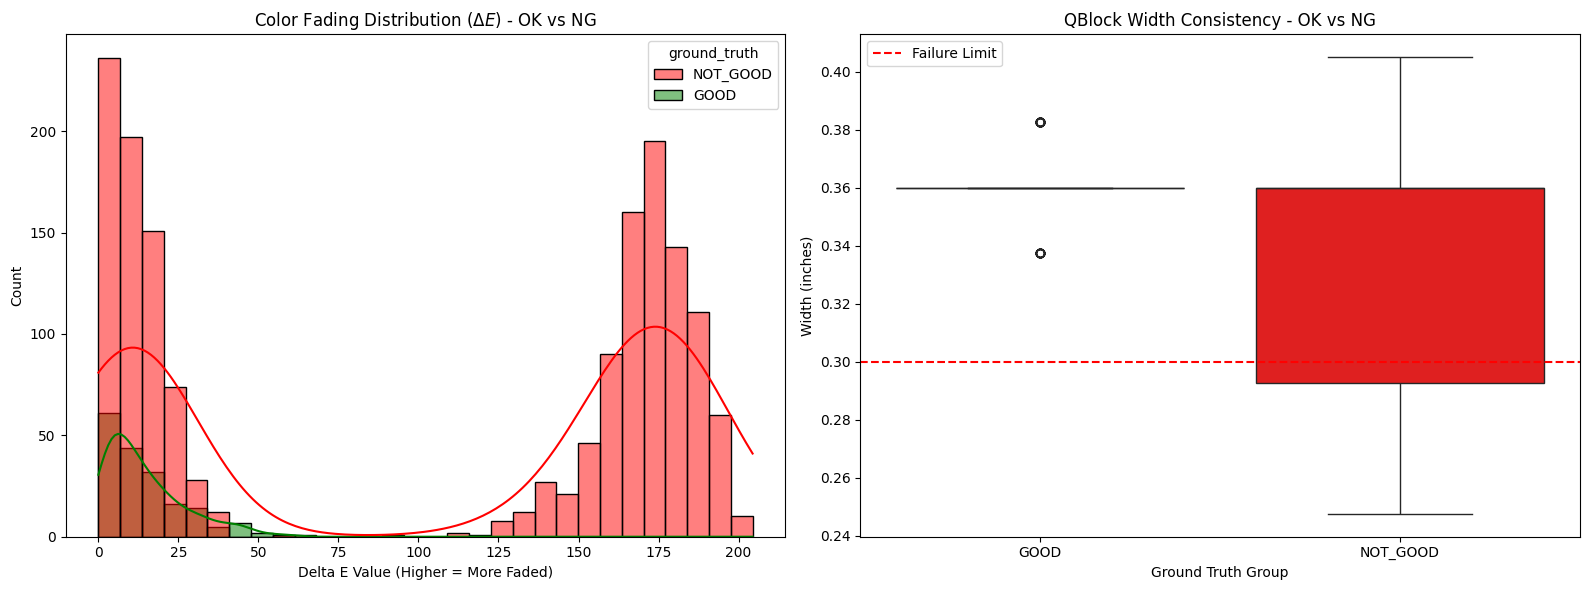

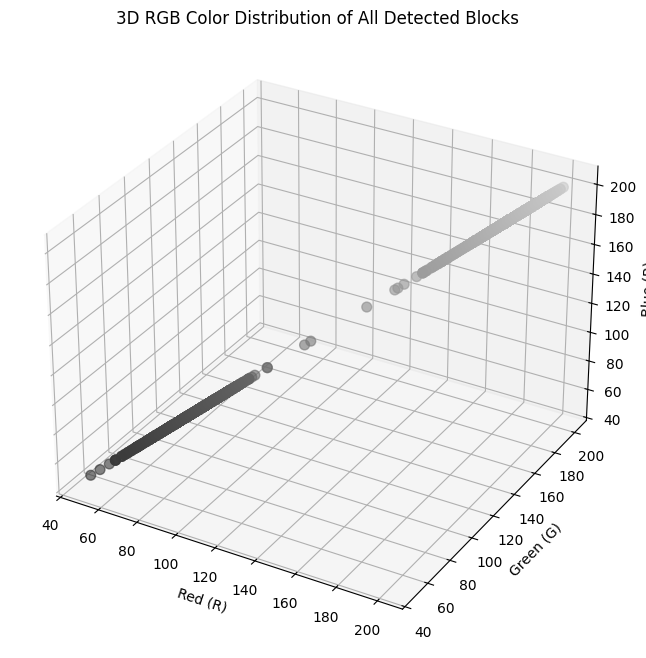

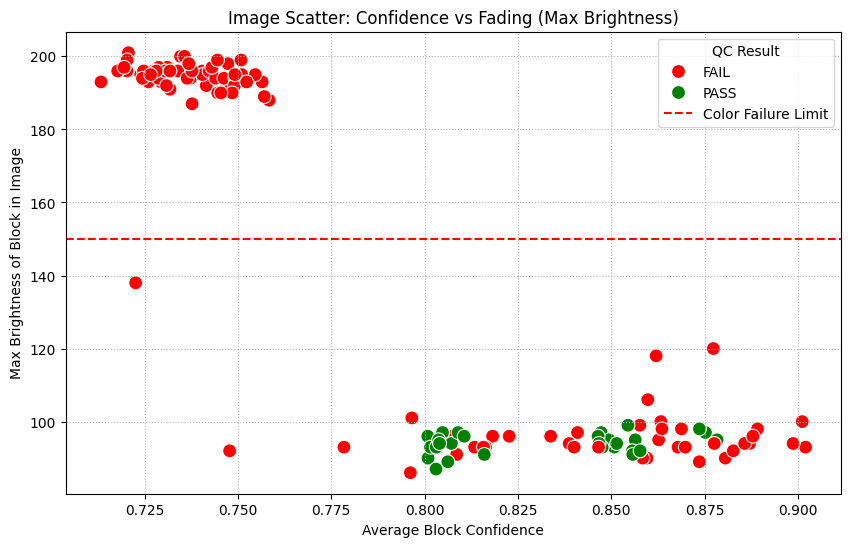


Detailed analysis complete.


In [11]:
# --- 📈 Phase 5: Detailed Static Visualizations ---

if 'df_blocks' not in globals() or df_blocks.empty:
    print("\nNo data available for visualization. Run previous cells.")
else:
    # 1. Prepare Plotting Data: Merge block data with image ground truth
    plot_df = pd.merge(df_blocks, df_images[['image_name', 'ground_truth']], on='image_name')
    plot_df = plot_df[plot_df['ground_truth'] != 'UNKNOWN'] # Only plot known GT images

    print("\nGenerating Detailed Visualizations...")

    # --- Chart 1: Fading Distribution (Delta E) ---
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(data=plot_df, x='Delta_E', hue='ground_truth',
                 palette={'GOOD': 'green', 'NOT_GOOD': 'red'}, kde=True, bins=30)
    plt.title('Color Fading Distribution ($\Delta E$) - OK vs NG')
    plt.xlabel('Delta E Value (Higher = More Faded)')
    plt.ylabel('Count')

    # --- Chart 2: Dimensional Distribution (Width) ---
    plt.subplot(1, 2, 2)
    sns.boxplot(x='ground_truth', y='Width_in', data=plot_df,
                palette={'GOOD': 'green', 'NOT_GOOD': 'red'}, order=['GOOD', 'NOT_GOOD'])
    plt.axhline(y=QC_MIN_WIDTH_IN, color='red', linestyle='--', label='Failure Limit')
    plt.title('QBlock Width Consistency - OK vs NG')
    plt.xlabel('Ground Truth Group')
    plt.ylabel('Width (inches)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Chart 3: RGB 3D Color Space Scatter ---
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(plot_df['r'], plot_df['g'], plot_df['b'],
               c=plot_df['hex_color'], s=50, alpha=0.6)

    ax.set_xlabel('Red (R)'); ax.set_ylabel('Green (G)'); ax.set_zlabel('Blue (B)')
    ax.set_title('3D RGB Color Distribution of All Detected Blocks')
    plt.show()

    # --- Chart 4: Confidence vs Fading/Size (Anomalous Blocks) ---
    qc_plot_df = qc_summary_df.copy()
    qc_plot_df['Failing'] = qc_plot_df['QC_PREDICTION'].apply(lambda x: 'FAIL' if x != 'PASS' else 'PASS')

    plt.figure(figsize=(10, 6))
    # FIX APPLIED: Use Avg_Confidence for the x-axis
    sns.scatterplot(data=qc_plot_df, x='Avg_Confidence', y='Max_Brightness', hue='Failing',
                    palette={'PASS': 'green', 'FAIL': 'red'}, s=100)

    # Add QC lines for reference
    plt.axhline(y=QC_MAX_BRIGHTNESS, color='red', linestyle='--', label='Color Failure Limit')

    plt.title('Image Scatter: Confidence vs Fading (Max Brightness)')
    plt.xlabel('Average Block Confidence') # Label updated to reflect aggregation
    plt.ylabel('Max Brightness of Block in Image')
    plt.legend(title='QC Result')
    plt.grid(True, linestyle=':')
    plt.show()

    print("\nDetailed analysis complete.")


Generating Detailed Visualizations (Dimensional and Color Analysis)...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


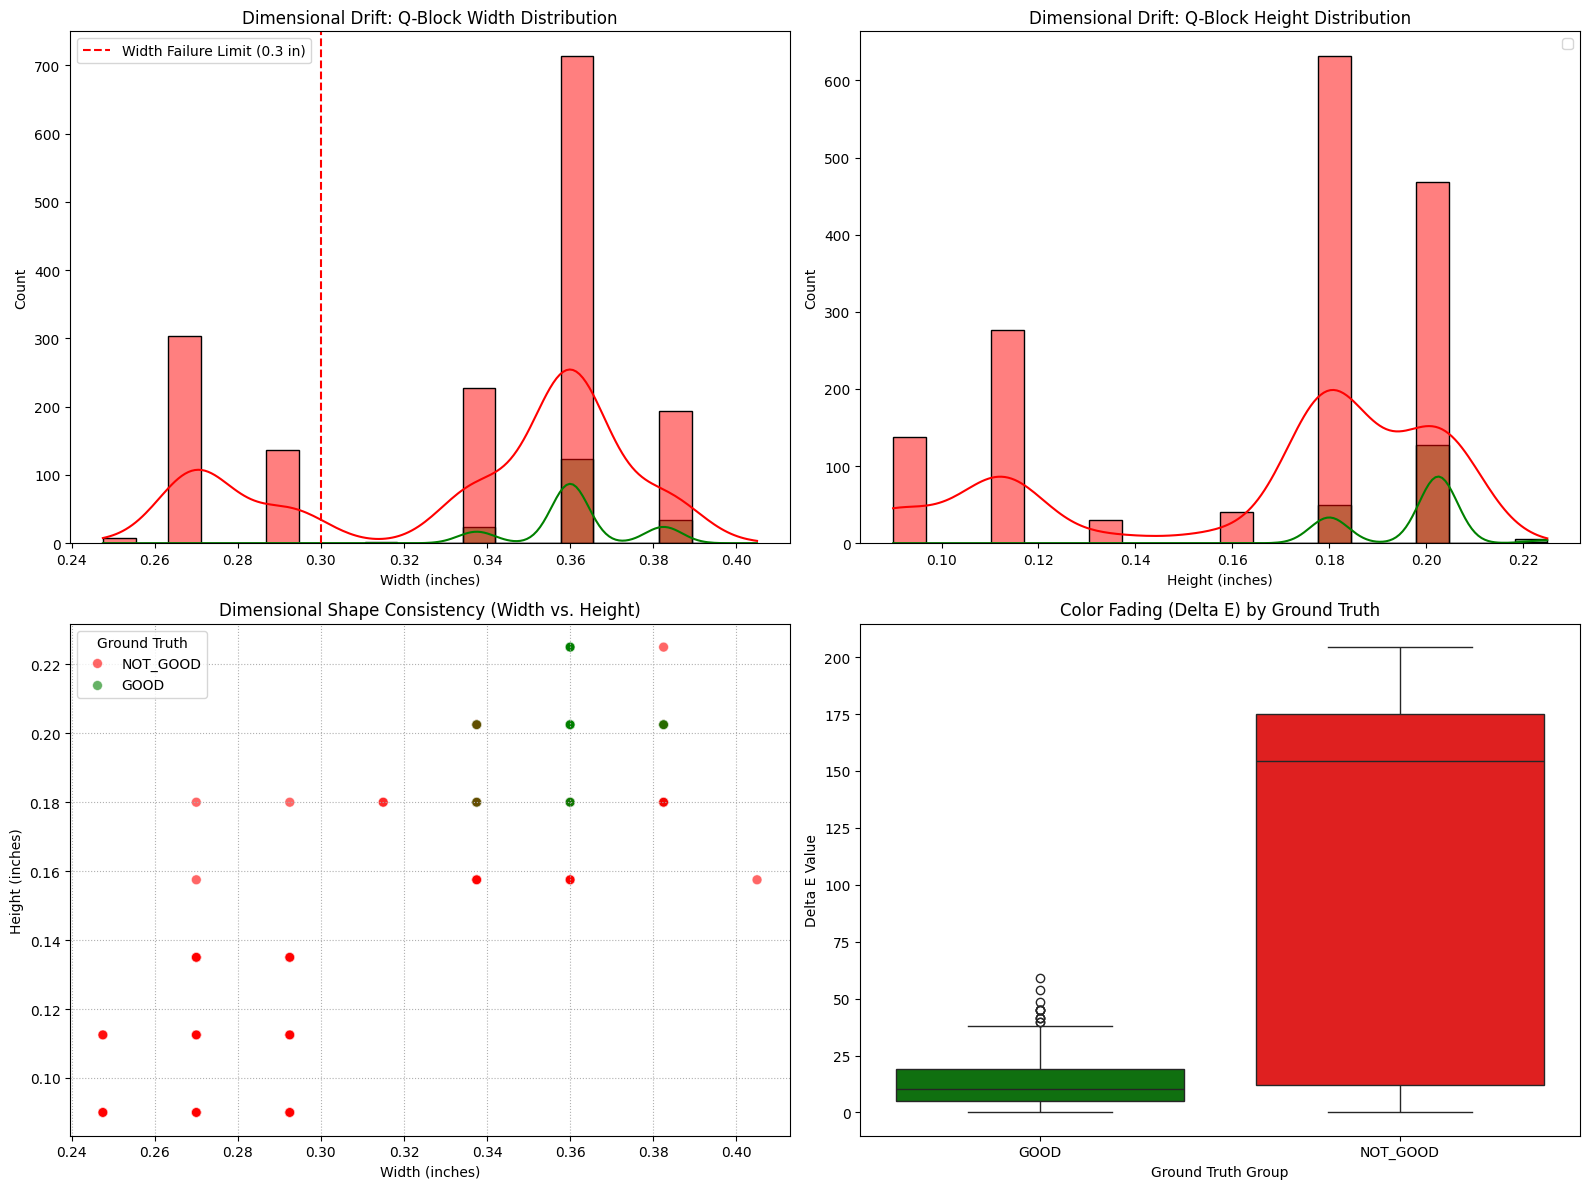

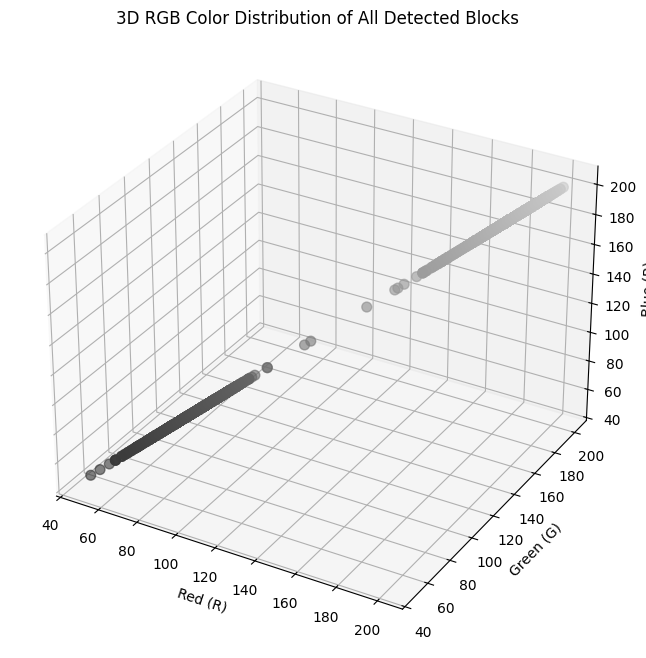

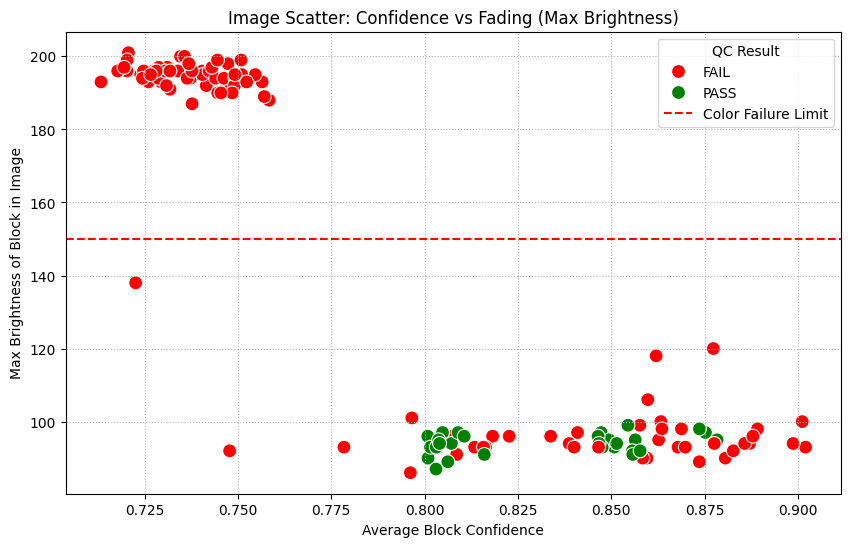


Detailed dimensional and color analysis complete.


In [13]:
# --- 📈 Phase 5: Detailed Static Visualizations ---

# Note: df_blocks, df_images, and qc_summary_df must be available from Cells 4 and 5.

if 'df_blocks' not in globals() or df_blocks.empty:
    print("\nFATAL ERROR: Data not found. Please ensure all previous cells (1-5) were run successfully.")
else:
    # 1. Prepare Plotting Data: Merge block data with image ground truth
    plot_df = pd.merge(df_blocks, df_images[['image_name', 'ground_truth']], on='image_name')
    plot_df = plot_df[plot_df['ground_truth'] != 'UNKNOWN']

    print("\nGenerating Detailed Visualizations (Dimensional and Color Analysis)...")

    plt.figure(figsize=(16, 12))

    # --- Chart 1: Q-Block Width Distribution (Histogram) ---
    plt.subplot(2, 2, 1)
    sns.histplot(data=plot_df, x='Width_in', hue='ground_truth',
                 palette={'GOOD': 'green', 'NOT_GOOD': 'red'}, kde=True, bins=20)
    plt.axvline(x=QC_MIN_WIDTH_IN, color='red', linestyle='--', label=f'Width Failure Limit ({QC_MIN_WIDTH_IN} in)')
    plt.title('Dimensional Drift: Q-Block Width Distribution')
    plt.xlabel('Width (inches)')
    plt.ylabel('Count')
    plt.legend()

    # --- Chart 2: Q-Block Height Distribution (Histogram) ---
    plt.subplot(2, 2, 2)
    sns.histplot(data=plot_df, x='Height_in', hue='ground_truth',
                 palette={'GOOD': 'green', 'NOT_GOOD': 'red'}, kde=True, bins=20)
    plt.title('Dimensional Drift: Q-Block Height Distribution')
    plt.xlabel('Height (inches)')
    plt.ylabel('Count')
    plt.legend()

    # --- Chart 3: Q-Block Width vs. Height Scatter (Shape Consistency) ---
    plt.subplot(2, 2, 3)
    sns.scatterplot(data=plot_df, x='Width_in', y='Height_in', hue='ground_truth',
                    palette={'GOOD': 'green', 'NOT_GOOD': 'red'}, alpha=0.6, s=50)
    plt.title('Dimensional Shape Consistency (Width vs. Height)')
    plt.xlabel('Width (inches)')
    plt.ylabel('Height (inches)')
    plt.grid(True, linestyle=':')
    plt.legend(title='Ground Truth')

    # --- Chart 4: Fading Distribution (Delta E Box Plot) ---
    plt.subplot(2, 2, 4)
    sns.boxplot(x='ground_truth', y='Delta_E', data=plot_df,
                palette={'GOOD': 'green', 'NOT_GOOD': 'red'}, order=['GOOD', 'NOT_GOOD'])
    plt.title('Color Fading (Delta E) by Ground Truth')
    plt.xlabel('Ground Truth Group')
    plt.ylabel('Delta E Value')

    plt.tight_layout()
    plt.show()

    # --- Additional Plot 1: RGB 3D Color Space Scatter ---
    # This chart helps visualize clustering of faded/off-color blocks.
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(plot_df['r'], plot_df['g'], plot_df['b'],
               c=plot_df['hex_color'], s=50, alpha=0.6)

    ax.set_xlabel('Red (R)'); ax.set_ylabel('Green (G)'); ax.set_zlabel('Blue (B)')
    ax.set_title('3D RGB Color Distribution of All Detected Blocks')
    plt.show()

    # --- Additional Plot 2: Confidence vs Fading/Size (Anomalous Blocks) ---
    # This chart helps identify images where low confidence correlates with poor quality.
    if 'qc_summary_df' in globals() and not qc_summary_df.empty:
        qc_plot_df = qc_summary_df.copy()
        qc_plot_df['Failing'] = qc_plot_df['QC_PREDICTION'].apply(lambda x: 'FAIL' if x != 'PASS' else 'PASS')

        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=qc_plot_df, x='Avg_Confidence', y='Max_Brightness', hue='Failing',
                        palette={'PASS': 'green', 'FAIL': 'red'}, s=100)

        plt.axhline(y=QC_MAX_BRIGHTNESS, color='red', linestyle='--', label='Color Failure Limit')

        plt.title('Image Scatter: Confidence vs Fading (Max Brightness)')
        plt.xlabel('Average Block Confidence')
        plt.ylabel('Max Brightness of Block in Image')
        plt.legend(title='QC Result')
        plt.grid(True, linestyle=':')
        plt.show()

    print("\nDetailed dimensional and color analysis complete.")

## Predictive Maintenance (PdM) Control Charts


=== Predictive Maintenance Analysis & Control Charts ===

--- Current Machine Health (Latest Batch) ---
🚨 PDM WARNING (Fading): Brightness (142.91) exceeds Warning Limit (140). Maintenance Alert!
✅ Dimension: Within Warning Limits.


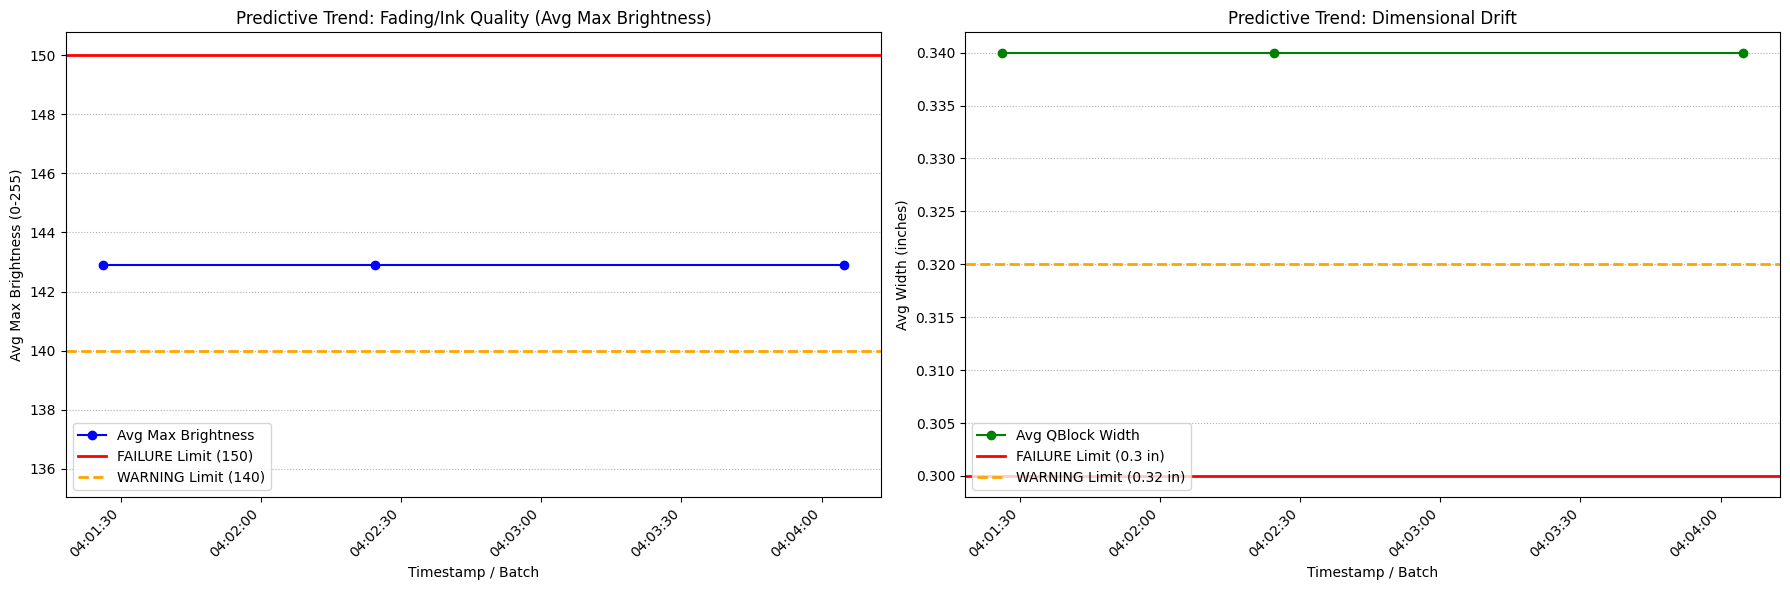


--- Predictive System Ready ---
Monitor the control charts for gradual drift towards the Warning/Failure limits.


In [12]:
# --- 🚀 Phase 6: Predictive Maintenance (PdM) Trending ---

if not os.path.exists(HISTORY_FILE_PATH) or len(pd.read_csv(HISTORY_FILE_PATH)) < 2:
    print(f"\nFATAL ERROR: Need more data points. Run Cell 5 at least twice to generate a trend history.")
else:
    df_history = pd.read_csv(HISTORY_FILE_PATH)
    df_history['Timestamp'] = pd.to_datetime(df_history['Timestamp'])

    print("\n=== Predictive Maintenance Analysis & Control Charts ===")

    # --- PdM Warning Check (Predictive Alarm) ---
    last_row = df_history.iloc[-1]
    print("\n--- Current Machine Health (Latest Batch) ---")

    if last_row['Max_Brightness_Trend'] > PDM_WARNING_BRIGHTNESS:
        print(f"🚨 PDM WARNING (Fading): Brightness ({last_row['Max_Brightness_Trend']:.2f}) exceeds Warning Limit ({PDM_WARNING_BRIGHTNESS}). Maintenance Alert!")
    else:
        print("✅ Fading: Within Warning Limits.")

    if last_row['Avg_Width_Trend'] < PDM_WARNING_MIN_WIDTH_IN:
        print(f"🚨 PDM WARNING (Dimension): Avg Width ({last_row['Avg_Width_Trend']:.4f} in) is below Warning Limit ({PDM_WARNING_MIN_WIDTH_IN} in). Maintenance Alert!")
    else:
        print("✅ Dimension: Within Warning Limits.")


    # --- Control Chart Generation ---
    plt.figure(figsize=(18, 6))

    # --- Chart 1: Fading Trend (Max Brightness) ---
    plt.subplot(1, 2, 1)
    plt.plot(df_history['Timestamp'], df_history['Max_Brightness_Trend'],
             marker='o', linestyle='-', color='blue', label='Avg Max Brightness')

    # Add Control Limits
    plt.axhline(y=QC_MAX_BRIGHTNESS, color='red', linestyle='-', linewidth=2, label=f'FAILURE Limit ({QC_MAX_BRIGHTNESS})')
    plt.axhline(y=PDM_WARNING_BRIGHTNESS, color='orange', linestyle='--', linewidth=2, label=f'WARNING Limit ({PDM_WARNING_BRIGHTNESS})')

    plt.title('Predictive Trend: Fading/Ink Quality (Avg Max Brightness)')
    plt.xlabel('Timestamp / Batch')
    plt.ylabel('Avg Max Brightness (0-255)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':')
    plt.legend()

    # --- Chart 2: Dimensional Trend (Avg Width) ---
    plt.subplot(1, 2, 2)
    plt.plot(df_history['Timestamp'], df_history['Avg_Width_Trend'],
             marker='o', linestyle='-', color='green', label='Avg QBlock Width')

    # Add Control Limits
    plt.axhline(y=QC_MIN_WIDTH_IN, color='red', linestyle='-', linewidth=2, label=f'FAILURE Limit ({QC_MIN_WIDTH_IN} in)')
    plt.axhline(y=PDM_WARNING_MIN_WIDTH_IN, color='orange', linestyle='--', linewidth=2, label=f'WARNING Limit ({PDM_WARNING_MIN_WIDTH_IN} in)')

    plt.title('Predictive Trend: Dimensional Drift')
    plt.xlabel('Timestamp / Batch')
    plt.ylabel('Avg Width (inches)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("\n--- Predictive System Ready ---")
    print("Monitor the control charts for gradual drift towards the Warning/Failure limits.")